<a href="http://landlab.github.io"><img style="float: left" src="https://raw.githubusercontent.com/landlab/tutorials/master/landlab_header.png"></a>

# Linking linear diffusion and fluvial incision, using steady state hydrology

Versions of this model are common in the landscape evolution literature. In the model illustrated here, linear diffusion (e.g. Tucker and Bras, 1998, WRR, available <a href="http://onlinelibrary.wiley.com/doi/10.1029/98WR01474/full">here</a>) and detachment-limited incision (e.g. Howard, 1994, WRR, available <a href="http://onlinelibrary.wiley.com/doi/10.1029/94WR00757/full">here</a>) are operating everywhere on the landscape. Process competition leads to convex hillslopes at lower drainage area and concave channels at higher drainage area. Both of the suggested papers have great illustrations of these process interactions.

In this example, some illustrative things to change might be:
  * hillslope diffusivity
  * the stream-power coefficient and/or exponents
  * uplift rate
  * the flow routing method
  * grid size
  * boundary conditions
  * your idea here!

#### Landlab Basics
To use a Jupyter Notebook to run Landlab, first we import the libraries (code) we need from Landlab, as well as standard plotting functions and numpy.   <br/>
In Landlab, processes are called components.<br/>
Every component is a class. <br/>
The grid is also a class.<br/>  

### Import Landlab and plotting libraries

In [9]:
from landlab.plot import imshow_grid
from landlab import RasterModelGrid

from landlab.components import FlowAccumulator, FastscapeEroder, LinearDiffuser, PerronNLDiffuse, TaylorNonLinearDiffuser

from matplotlib.pyplot import figure, show, plot, xlabel, ylabel, title
from matplotlib import pyplot as plt
%matplotlib inline

import numpy as np

### Set up initial topography
* Instantiate a grid object, here we call it `mg`.

* Set the boundary conditions. In this case the top and bottom edges are fixed value, or open (water and sediment can pass out of the top and bottom boundaries). The right and left edges are closed.

* Make a rough surface as the initial topography.

* Make a plot to see the initial topography.

In [2]:
# # The grid is 200 rows by 150 columns, with dx = dy = 50 m.
# cell_width_length=40
# rows=180
# colums=180

# mg = RasterModelGrid((rows, colums), cell_width_length)

# mg.set_closed_boundaries_at_grid_edges(
#     right_is_closed=True,
#     top_is_closed=False,
#     left_is_closed=True,
#     bottom_is_closed=False
# )

# # Create an initial elevation field with some random perturbations.
# z = 100+mg.add_zeros('node', 'topographic__elevation')
# initial_roughness = np.random.rand(mg.core_nodes.size)/5
# mg.at_node['topographic__elevation'][mg.core_nodes] += initial_roughness

# # Plot the elevation field.
# imshow_grid(mg, z, grid_units=['m','m'], var_name='Elevation (m)')

Loaded: /mnt/c/Users/amehedi/Downloads/BoltCreek_All_USGS_Ref_DEM_10m.asc
Grid shape: (400, 403), dx=10.0


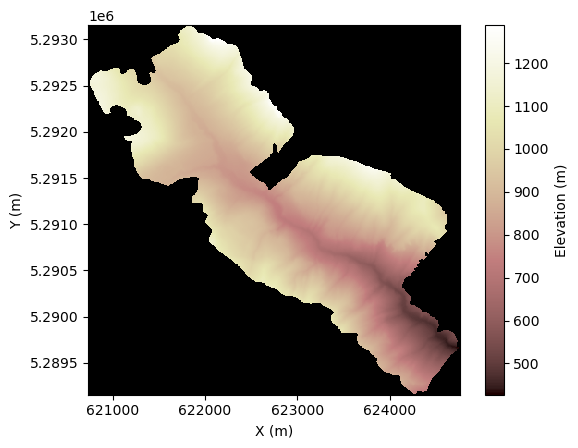

In [10]:
from pathlib import Path
from landlab.io import esri_ascii
from landlab.plot import imshow_grid

# asc_dir = Path("/home/abdullah/fire-debrisflow-ml/data")
# dem_path = asc_dir / "BoltCreek_USGS_1m_DEM_Reference_A.asc"

# # Load DEM as Landlab grid + node field "BoltCreek_USGS_1m_DEM_Reference_A.asc"
# with dem_path.open("r") as f:
#     mg = esri_ascii.load(f, name="BoltCreek_USGS_1m_DEM_Reference_A.asc"

# z = mg.at_node["BoltCreek_USGS_1m_DEM_Reference_A.asc"
# z_pre = mg.at_node["BoltCreek_USGS_1m_DEM_Reference_A.asc"
# mg.set_nodata_nodes_to_closed(z, -999999)

# # Keep the same BC style as your current notebook
# mg.set_closed_boundaries_at_grid_edges(
#     right_is_closed=True,
#     top_is_closed=False,
#     left_is_closed=True,
#     bottom_is_closed=False,
# )

# imshow_grid(mg, "BoltCreek_USGS_1m_DEM_Reference_A.asc"evation (m)")
# print(f"Loaded: {dem_path}")
# print(f"Grid shape: {mg.shape}, dx={mg.dx}")

from pathlib import Path
import numpy as np
from landlab.io import esri_ascii
from landlab.plot import imshow_grid

asc_dir = Path("/mnt/c/Users/amehedi/Downloads/")
dem_path = asc_dir / "BoltCreek_All_USGS_Ref_DEM_10m.asc"
nodata = -9999.0 #-999999.0

# Load DEM file, but map it to the standard Landlab field name
with dem_path.open("r") as f:
    mg = esri_ascii.load(f, name="topographic__elevation")

z = mg.at_node["topographic__elevation"]
z_pre = z.copy()
nodata_mask = (z_pre == nodata)

mg.set_nodata_nodes_to_closed(z_pre, nodata)
mg.set_closed_boundaries_at_grid_edges(
    right_is_closed=True,
    top_is_closed=False,
    left_is_closed=True,
    bottom_is_closed=False,
)

imshow_grid(mg, "topographic__elevation", grid_units=["m", "m"], var_name="Elevation (m)")
print(f"Loaded: {dem_path}")
print(f"Grid shape: {mg.shape}, dx={mg.dx}")

In [11]:
from pathlib import Path
import numpy as np

dem_path = Path("/mnt/c/Users/amehedi/Downloads/BoltCreek_All_USGS_Ref_DEM_10m.asc")
nodata = -9999.0 #-999999.0

with dem_path.open("r") as f:
    mg = esri_ascii.load(f, name="topographic__elevation")

z = mg.at_node["topographic__elevation"]
valid = np.isfinite(z) & (z != nodata)

print("n_total:", z.size)
print("n_valid:", valid.sum())
print("min:", float(np.min(z[valid])))
print("max:", float(np.max(z[valid])))
print("mean:", float(np.mean(z[valid])))
print("std:", float(np.std(z[valid])))
print("p05,p50,p95:", np.percentile(z[valid], [5, 50, 95]))

n_total: 161200
n_valid: 60802
min: 427.100341796875
max: 1288.3839111328125
mean: 907.0099634070338
std: 159.54198913712088
p05,p50,p95: [ 601.51418457  919.94284058 1147.99857788]


### Initialize time and uplift for the model run.

* Note that units are not imposed by many of the Landlab components, and the grid has no assumed units.

Loaded: /mnt/c/Users/amehedi/Downloads/ml_debris/output/thomas/dem_pre.asc
Grid shape: (835, 716), dx=10.0
Completed loop 0 out of 49


/tmp/ipykernel_1584/2119800726.py:77: FutureWarning: Calling `add_field` with the field location as the first argument is deprecated and will be removed in future versions. Instead, please use the `at` keyword to specify the location: add_field(arg0, arg1, at='node').
  mg.add_field("node", "diff", diff, clobber=True)


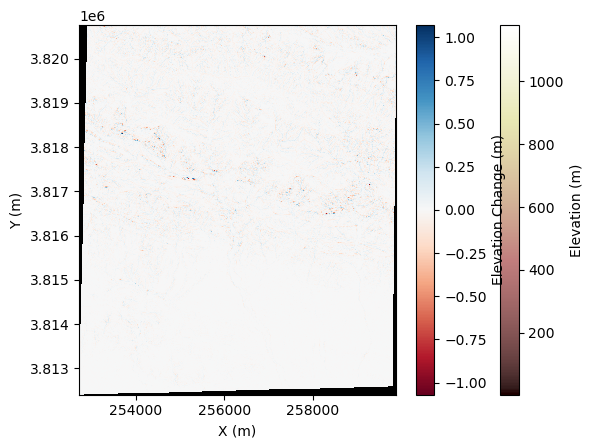

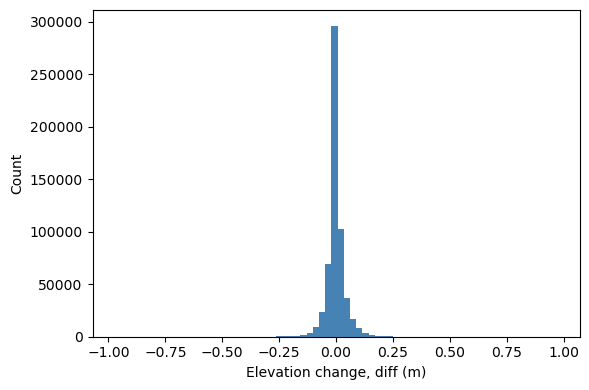

In [3]:
from pathlib import Path
import numpy as np
from landlab.io import esri_ascii
from landlab.plot import imshow_grid

asc_dir = Path("/mnt/c/Users/amehedi/Downloads/ml_debris/output/thomas")
dem_path = asc_dir / "dem_pre.asc"
nodata = -9999.0 #-999999.0

# Load DEM file, but map it to the standard Landlab field name
with dem_path.open("r") as f:
    mg = esri_ascii.load(f, name="topographic__elevation")

z = mg.at_node["topographic__elevation"]
z_pre = z.copy()
nodata_mask = (z_pre == nodata)

mg.set_nodata_nodes_to_closed(z_pre, nodata)
mg.set_closed_boundaries_at_grid_edges(
    right_is_closed=True,
    top_is_closed=False,
    left_is_closed=True,
    bottom_is_closed=False,
)

imshow_grid(mg, "topographic__elevation", grid_units=["m", "m"], var_name="Elevation (m)")
print(f"Loaded: {dem_path}")
print(f"Grid shape: {mg.shape}, dx={mg.dx}")


# Time / uplift setup
total_t = 5.0  # years
dt = 0.1      # years
nt = int(total_t // dt)

uplift_rate = 0.0003          # m/year
uplift_per_step = uplift_rate * dt  # m per step

Mean_elev = []

# Non-linear diffusion component (stable settings)
k_d_nonlin = 0.1
Sc = 0.60

Taylor_nonlin_diffuse = TaylorNonLinearDiffuser(
    mg,
    linear_diffusivity=k_d_nonlin,
    slope_crit=Sc,
    nterms=2,
    dynamic_dt=True,
    if_unstable="raise",
    courant_factor=0.2,
)

# Loop
core = mg.core_nodes
z = mg.at_node["topographic__elevation"]

for i in range(nt):
    Taylor_nonlin_diffuse.run_one_step(dt)
    # fr.run_one_step()
    # sp.run_one_step(dt)

    # z[core] += uplift_per_step
    Mean_elev.append(np.mean(z[core]))

    if i % 500 == 0:
        print(f"Completed loop {i} out of {nt}")

z_post = mg.at_node["topographic__elevation"].copy()



diff = z_post - z_pre
diff[nodata_mask] = nodata

mg.add_field("node", "diff", diff, clobber=True)
mg.set_nodata_nodes_to_closed(diff, nodata)

imshow_grid(
    mg,
    "diff",
    grid_units=["m", "m"],
    var_name="Elevation Change (m)",
    limits=(-1.07, 1.07),   # value/color range
    cmap="RdBu",
    symmetric_cbar=True,
)
plt.show()

# Histogram
valid = np.isfinite(diff) & (diff != nodata)
plt.figure(figsize=(6, 4))
plt.hist(diff[valid], bins=80, color="steelblue", edgecolor="none")
plt.xlim(-1.07, 1.07)
plt.xlabel("Elevation change, diff (m)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Loaded: /mnt/c/Users/amehedi/Downloads/BoltCreek_All_USGS_Ref_DEM_10m.asc
Grid shape: (400, 403), dx=10.0
Completed loop 0 / 49
Completed loop 4 / 49
Completed loop 8 / 49
Completed loop 12 / 49
Completed loop 16 / 49
Completed loop 20 / 49
Completed loop 24 / 49
Completed loop 28 / 49
Completed loop 32 / 49
Completed loop 36 / 49
Completed loop 40 / 49
Completed loop 44 / 49
Completed loop 48 / 49


/tmp/ipykernel_1584/3582726860.py:100: FutureWarning: Calling `add_field` with the field location as the first argument is deprecated and will be removed in future versions. Instead, please use the `at` keyword to specify the location: add_field(arg0, arg1, at='node').
  mg.add_field("node", "diff", diff, clobber=True)


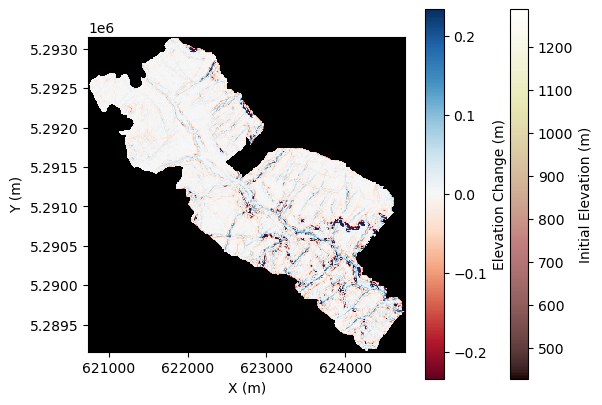

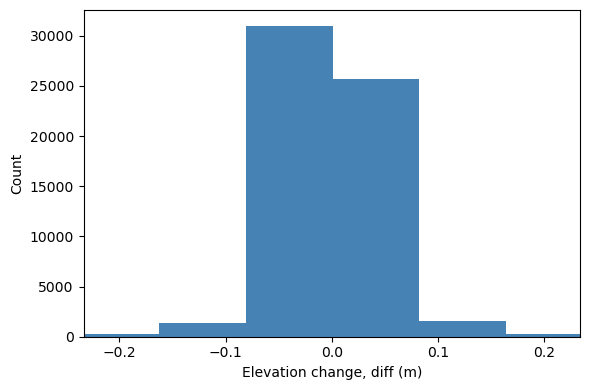

In [12]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from landlab.io import esri_ascii
from landlab.plot import imshow_grid
from landlab.components import TaylorNonLinearDiffuser, FlowAccumulator, FastscapeEroder

# ---------------------------
# 1) Load DEM (ASC)
# ---------------------------
asc_dir = Path("/mnt/c/Users/amehedi/Downloads/")
dem_path = asc_dir / "BoltCreek_All_USGS_Ref_DEM_10m.asc"
nodata = -9999.0 

with dem_path.open("r") as f:
    mg = esri_ascii.load(f, name="topographic__elevation")  # keep this field name

z = mg.at_node["topographic__elevation"]
z_pre = z.copy()
nodata_mask = (~np.isfinite(z_pre)) | np.isclose(z_pre, nodata)

mg.set_nodata_nodes_to_closed(z, nodata)
mg.set_closed_boundaries_at_grid_edges(
    right_is_closed=True,
    top_is_closed=False,
    left_is_closed=True,
    bottom_is_closed=False,
)

imshow_grid(mg, "topographic__elevation", grid_units=["m", "m"], var_name="Initial Elevation (m)")
print(f"Loaded: {dem_path}")
print(f"Grid shape: {mg.shape}, dx={mg.dx}")


# ---------------------------
# 2) Model setup
# ---------------------------
total_t = 5.0     # years
dt = 0.1          # years
nt = int(total_t // dt)

uplift_rate = 0.0003
uplift_per_step = uplift_rate * dt
Mean_elev = []

k_d_nonlin = 0.1
Sc = 0.60

Taylor_nonlin_diffuse = TaylorNonLinearDiffuser(
    mg,
    linear_diffusivity=k_d_nonlin,
    slope_crit=Sc,
    nterms=2,
    dynamic_dt=True,
    if_unstable="raise",
    courant_factor=0.2,
)

# Optional process switches
run_flow = False
run_sp = False
add_uplift = False

if run_flow:
    fr = FlowAccumulator(mg, flow_director="FlowDirectorD8")
if run_sp:
    K_sp, m_sp, n_sp = 1e-5, 0.5, 1.0
    sp = FastscapeEroder(mg, K_sp=K_sp, m_sp=m_sp, n_sp=n_sp, threshold_sp=0.0)

# ---------------------------
# 3) Run loop
# ---------------------------
core = mg.core_nodes
z = mg.at_node["topographic__elevation"]

for i in range(nt):
    Taylor_nonlin_diffuse.run_one_step(dt)

    if run_flow:
        fr.run_one_step()
    if run_sp:
        sp.run_one_step(dt)
    if add_uplift:
        z[core] += uplift_per_step

    Mean_elev.append(float(np.mean(z[core])))

    if i % max(1, nt // 10) == 0:
        print(f"Completed loop {i} / {nt}")

z_post = z.copy()

# ---------------------------
# 4) Elevation change (diff)
# ---------------------------
diff = z_post - z_pre
diff[nodata_mask] = nodata

mg.add_field("node", "diff", diff, clobber=True)
mg.set_nodata_nodes_to_closed(mg.at_node["diff"], nodata)

valid = np.isfinite(diff) & (~np.isclose(diff, nodata))
v = np.percentile(np.abs(diff[valid]), 99) if np.any(valid) else 1.0

imshow_grid(
    mg,
    "diff",
    grid_units=["m", "m"],
    var_name="Elevation Change (m)",
    limits=(-v, v),
    cmap="RdBu",
    symmetric_cbar=True,
)
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(diff[valid], bins=80, color="steelblue", edgecolor="none")
plt.xlim(-v, v)
plt.xlabel("Elevation change, diff (m)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

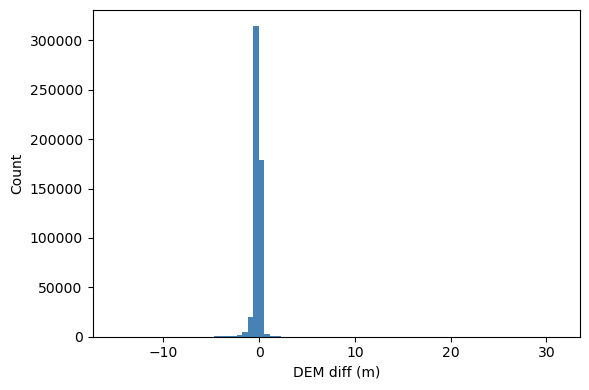

n: 529116 min: -15.07989501953125 max: 31.199615478515625 mean: -0.1313469558954239 std: 0.6706097722053528


In [8]:
tif = "/mnt/c/Users/amehedi/Downloads/ml_debris/output/thomas/dem_diff.tif"

with rasterio.open(tif) as src:
    arr = src.read(1)
    nodata = src.nodata

valid = np.isfinite(arr)
if nodata is not None:
    valid &= (arr != nodata)

x = arr[valid]

plt.figure(figsize=(6,4))
plt.hist(x, bins=80, color="steelblue", edgecolor="none")
plt.xlabel("DEM diff (m)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("n:", x.size, "min:", float(x.min()), "max:", float(x.max()), "mean:", float(x.mean()), "std:", float(x.std()))


In [15]:
import rasterio
out_tif = Path("/mnt/c/Users/amehedi/Downloads/dem_diff_bolt_full_10m_5y_k0.1_sc0.6.tif")
# tmp_asc = Path("/tmp/dem_diff.asc")
crs_ref_tif = Path("/home/abdullah/fire-debrisflow-ml/data/landslide__probability_of_failure_epsg32610.tif")
# crs_ref_tif = Path("/mnt/c/Users/amehedi/Downloads/ml_debris/output/thomas/topographic__elevation.tif")

nodata_out = -9999.0 #-999999.0

if "diff" not in mg.at_node:
    raise ValueError("mg.at_node['diff'] not found. Create diff first.")

# Correct Landlab dump call: dump(grid, stream, at, name)
with tmp_asc.open("w") as f:
    esri_ascii.dump(mg, f, at="node", name="diff")

# Read ASCII and attach CRS from reference raster
with rasterio.open(tmp_asc) as src, rasterio.open(crs_ref_tif) as ref:
    arr = src.read(1).astype("float32")
    src_nodata = src.nodata if src.nodata is not None else nodata_out
    arr[np.isclose(arr, src_nodata)] = nodata_out

    profile = src.profile.copy()
    profile.update(
        driver="GTiff",
        dtype="float32",
        count=1,
        nodata=nodata_out,
        crs=ref.crs,
        compress="LZW",
    )

out_tif.parent.mkdir(parents=True, exist_ok=True)
with rasterio.open(out_tif, "w", **profile) as dst:
    dst.write(arr, 1)

print("Saved:", out_tif)
print("CRS:", profile["crs"])

Saved: /mnt/c/Users/amehedi/Downloads/dem_diff_bolt_full_10m_5y_k0.1_sc0.6.tif
CRS: EPSG:32610


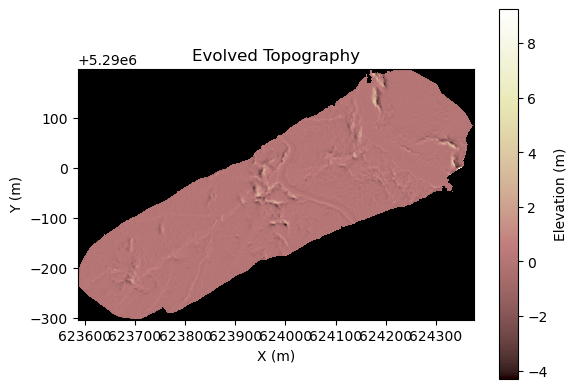

In [31]:
imshow_grid(mg, diff, grid_units=['m','m'], var_name='Elevation (m)')
plt.title('Evolved Topography')
plt.show()

### Instantiate the process components for this model
In this case the difference components are:
  * `FlowAccumulator` which determines the drainage area at each point. In this case we are using `D8` to determine downslope neighbors.
  * `FastscapeEroder` which calculates the incision rate based on a power-law function of discharge and slope. This uses the Braun and Willet algorithm, reference <a href="http://www.sciencedirect.com/science/article/pii/S0169555X12004618">here</a>)
  * `Diffusers` which calculates erosion and deposition of material using a sediment transport rate which is proportional to the slope.
  * Note that in the case of `FastscapeEroder`, the values are noted when the class is instantiated. In the case of the `LinearDiffuser`, the value is assigned to a variable and that variable is sent to the class. There are multiple ways to do things, depending on your coding style and what makes sense to you.
  * Remember that the grid was made with an assumed dx in meters. Time values are in years. So any parameters should have units of meters and years.

In [5]:
# Choose diffusivity value and instantiate objects for hillslope diffusion and assign parameter values

# Option 1: LinearDiffuser
k_d = 0.01  # m2/y this is a high-end for this parameter
lin_diffuse = LinearDiffuser(mg, linear_diffusivity=k_d, deposit=True)

# Option 2: Non-linear Diffusion
k_d_nonlin=0.01    # 0.01-0.03   for Oregon like forest, first number with fires second w/o
Sc=1.125           # 1-1.25      for Oregon like forest, first number with fires second w/o
Taylor_nonlin_diffuse = TaylorNonLinearDiffuser(mg, linear_diffusivity=k_d_nonlin, slope_crit=Sc, if_unstable='warn')

# NOTE that if deposit=True, the slope area data will look different.

In [6]:
# Instantiate an object of the FlowAccumulator
fr = FlowAccumulator(mg, flow_director='FlowDirectorD8')

# Choose parameter values for the stream power (SP) equation
# and instantiate an object of the FastscapeEroder
K_sp=0.00001 # erodibility in SP eqtn, units depend on m_sp (0.00001 for m=0.5) (0.00005 for m=0.25)
m_sp=0.5 # exponent on drainage area in SP eqtn
n_sp=1 # exponent on slope in the SP eqtn

sp = FastscapeEroder(mg, K_sp=K_sp, m_sp=m_sp, n_sp=n_sp, threshold_sp=0)

* The calculations are all done in the time loop below.

In [ ]:
for i in range(nt):

    lin_diffuse.run_one_step(dt) # linear diffusion
    fr.run_one_step() # route flow
    sp.run_one_step(dt) # fluvial (SP) incision

    mg.at_node['topographic__elevation'][mg.core_nodes] += uplift_per_step # add the uplift
    Mean_elev.append(np.mean(mg.at_node['topographic__elevation'][mg.core_nodes]))
    if i % 500 == 0:
      print ("Completed loop", i, "out of", nt)

Topographic slopes are high enough such that the Courant condition is exceeded AND you have not selected dynamic timestepping with dynamic_dt=True. This may lead to infinite and/or nan values for slope, elevation, and soil depth. Consider using a smaller time step or dynamic timestepping. The Courant condition recommends a timestep of 133.21542450644372 or smaller.
Completed loop 0 out of 5000
Topographic slopes are high enough such that the Courant condition is exceeded AND you have not selected dynamic timestepping with dynamic_dt=True. This may lead to infinite and/or nan values for slope, elevation, and soil depth. Consider using a smaller time step or dynamic timestepping. The Courant condition recommends a timestep of 16.142506664136636 or smaller.
Topographic slopes are high enough such that the Courant condition is exceeded AND you have not selected dynamic timestepping with dynamic_dt=True. This may lead to infinite and/or nan values for slope, elevation, and soil depth. Consi

/home/abdullah/miniconda3/envs/ml_debris/lib/python3.10/site-packages/landlab/components/taylor_nonlinear_hillslope_flux/taylor_nonlinear_hillslope_flux.py:268: RuntimeWarning: overflow encountered in scalar power
  courant_slope_term += courant_s_over_scrit**i


RuntimeError: Soil flux term is infinite in Courant condition calculation. This is likely due to using too many terms in the Taylor expansion.

### Visualize the results.
  * First we plot the topography after the time loop.
  * Second we plot the slope-area relationship, which is often used to identify hillslopes, channels, and quantify drainage density.

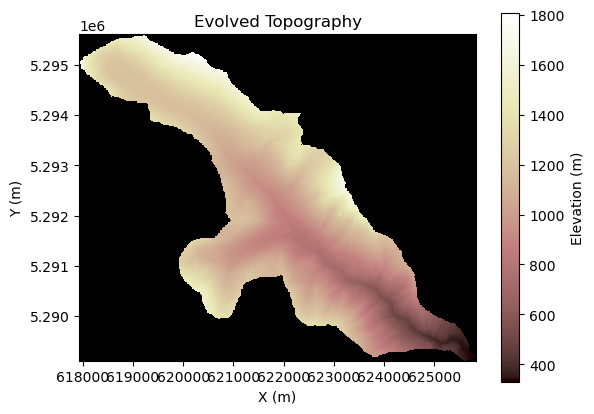

In [11]:
imshow_grid(mg, 'topographic__elevation', grid_units=['m','m'], var_name='Elevation (m)')
plt.title('Evolved Topography')
plt.show()

In [12]:
z_post = mg.at_node['topographic__elevation']

/tmp/ipykernel_127183/1378733573.py:3: FutureWarning: Calling `add_field` with the field location as the first argument is deprecated and will be removed in future versions. Instead, please use the `at` keyword to specify the location: add_field(arg0, arg1, at='node').
  mg.add_field('node','Slope',S, clobber=True)


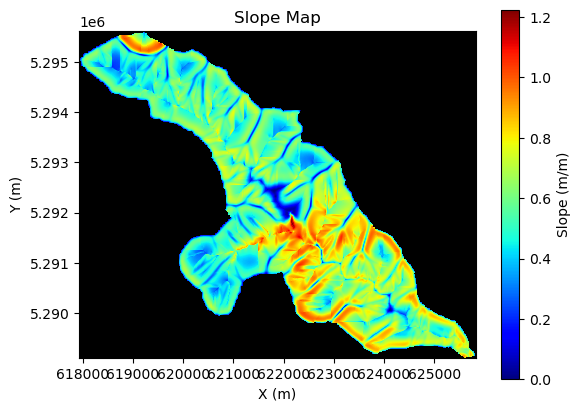

In [22]:
Z=mg.at_node['topographic__elevation']
S = mg.calc_slope_at_node(Z)   # let's call this a slope field and add it to the grid
mg.add_field('node','Slope',S, clobber=True)

imshow_grid(mg,'Slope', plot_name = 'Slope Map',
            var_name = 'Slope', var_units = 'm/m', grid_units = ('m','m'),cmap = 'jet')

**Plot of the mean elevation of the landscape**

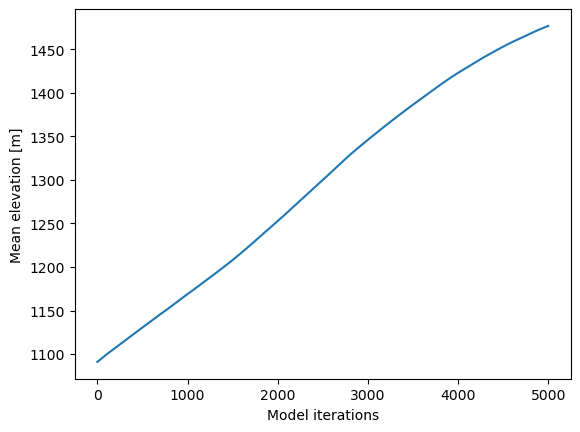

In [23]:
plot(Mean_elev)

plt.xlabel("Model iterations")
plt.ylabel("Mean elevation [m]")

plt.show()

**Plot the mean elevation of the landscape** which can be used to see if landscape dynamic equilibrium (or steady-state)

### plot some channel profiles.

Text(0, 0.5, 'channel slope [m/m]')

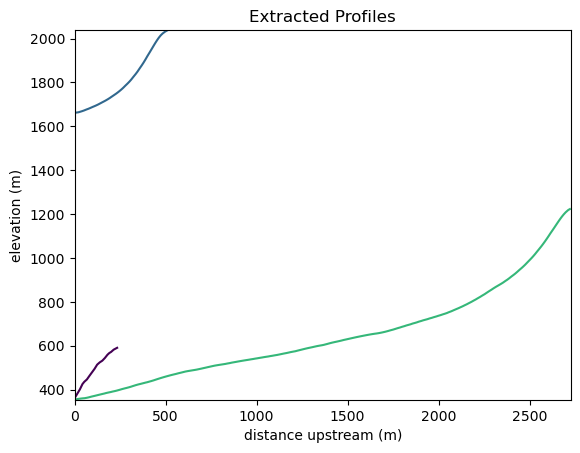

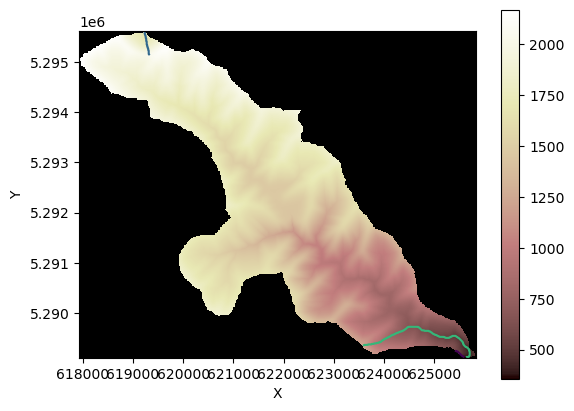

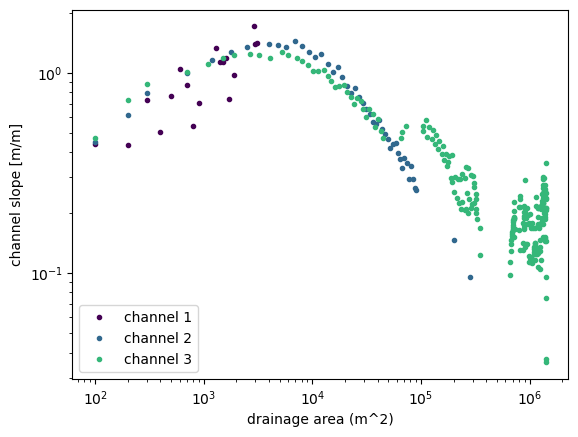

In [24]:
# Import the channel profile tool
from landlab.components import ChannelProfiler

# Instantiate an object of the ChannelProfiler
prf = ChannelProfiler(mg,
                      number_of_watersheds=3,
                      main_channel_only=True,
                      minimum_channel_threshold=1.0)
prf.run_one_step() # run_one_step just means we are finding the channels

# plot the elevation as a function of distance upstream
plt.figure(1)
#title_text = f"$K_{{sp}}$={K_sp}; $K_{{d}}$={k_d}"
prf.plot_profiles(xlabel='distance upstream (m)',
                  ylabel='elevation (m)')

# plot the location of the channels in map view
plt.figure(2)
prf.plot_profiles_in_map_view()
#title_text = f"$K_{{sp}}$={K_sp}; $K_{{d}}$={k_d}"
#_ = plt.title(title_text)

# slope-area data in just the profiled channels
plt.figure(3)
for i, outlet_id in enumerate(prf.data_structure):
    for j, segment_id in enumerate(prf.data_structure[outlet_id]):
        if j == 0:
            label = "channel {i}".format(i=i + 1)
        else:
            label = '_nolegend_'
        segment = prf.data_structure[outlet_id][segment_id]
        profile_ids = segment["ids"]
        color = segment["color"]
        plt.loglog(
            mg.at_node["drainage_area"][profile_ids],
            mg.at_node["topographic__steepest_slope"][profile_ids],
            '.',
            color=color,
            label=label,
        )

plt.legend(loc="lower left")
plt.xlabel("drainage area (m^2)")
plt.ylabel("channel slope [m/m]")
#_ = plt.title(title_text)

### Now let's plot channel steepness index and chi

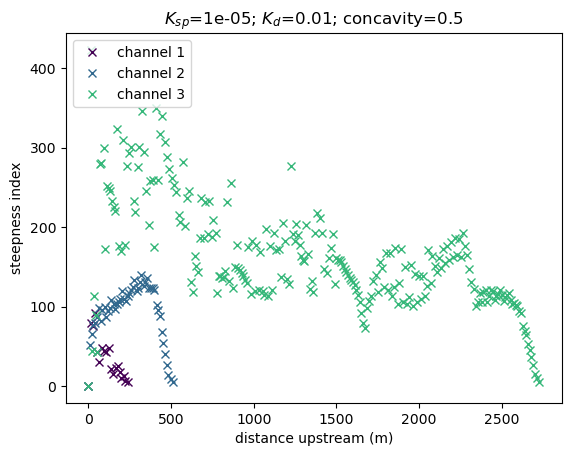

In [25]:
# Import the Landlab Components
from landlab.components import ChiFinder, SteepnessFinder

# calculate reference concavity
theta = m_sp/n_sp
# initialize the component that will calculate channel steepness
sf = SteepnessFinder(mg, reference_concavity=theta, min_drainage_area=1.0)

# calculate channel steepness
sf.calculate_steepnesses()

# plots of steepnes vs. distance upstream in the profiled channels
plt.figure(3)

for i, outlet_id in enumerate(prf.data_structure):
    for j, segment_id in enumerate(prf.data_structure[outlet_id]):
        if j == 0:
            label = "channel {i}".format(i=i + 1)
        else:
            label = '_nolegend_'
        segment = prf.data_structure[outlet_id][segment_id]
        profile_ids = segment["ids"]
        distance_upstream = segment["distances"]
        color = segment["color"]
        plt.plot(
            distance_upstream,
            mg.at_node["channel__steepness_index"][profile_ids],
            'x',
            color=color,
            label=label,
        )

plt.xlabel("distance upstream (m)")
plt.ylabel("steepness index")
plt.legend(loc="upper left")
_ = plt.title(
    f"$K_{{sp}}$={K_sp}; $K_{{d}}$={k_d}; concavity={theta}")

In [14]:
# initialize the component that will calculate the chi index
cf = ChiFinder(mg,
               min_drainage_area=1.0,
               reference_concavity=theta,
               use_true_dx=True)

# calculate the chi index
cf.calculate_chi()

# chi-elevation plots in the profiled channels
plt.figure(4)

for i, outlet_id in enumerate(prf.data_structure):
    for j, segment_id in enumerate(prf.data_structure[outlet_id]):
        if j == 0:
            label = "channel {i}".format(i=i + 1)
        else:
            label = '_nolegend_'
        segment = prf.data_structure[outlet_id][segment_id]
        profile_ids = segment["ids"]
        color = segment["color"]
        plt.plot(
            mg.at_node["channel__chi_index"][profile_ids],
            mg.at_node["topographic__elevation"][profile_ids],
            color=color,
            label=label,
        )

plt.xlabel("chi index (m)")
plt.ylabel("elevation (m)")
plt.legend(loc="lower right")
_ = plt.title(title_text)

FieldError: Unable to add the field, 'channel__chi_index', to the group, 'node', because a field with that name already exists in that group. Use `clobber=True` to replace the existing field. For example, grid.add_field('channel__chi_index', at='node', clobber=True)

### Edit the model and rerun it.
* Remember if you edit any of the code, you need to re-run the edited code block.
* If you re-run the time loop, it will operate on the existing topography. If you want to start over on a flat surface, then you need to re-run the code block that instantiated the grid.